In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Detect ROUGE column name
def get_rouge_col(df):
    if "rougeL" in df.columns:
        return "rougeL"
    if "rogueL" in df.columns:  # your typo possibility
        return "rogueL"
    raise ValueError("No rougeL or rogueL column found.")

In [ ]:
results = []

for path in glob.glob("/content/*_docstr.csv"):
    name = os.path.basename(path)
    print(f"\n=== Processing {name} ===")

    df = pd.read_csv(path)
    rouge_col = get_rouge_col(df)

    diffs_judge_abs = []
    diffs_rouge_abs = []
    diffs_judge_pct = []
    diffs_rouge_pct = []

    for _, g in df.groupby("comment_original"):
        # Expect exactly 2 rows: has_docstr=True and False
        if len(g) != 2:
            continue

        row_true = g[g["has_docstr"] == True]
        row_false = g[g["has_docstr"] == False]

        if len(row_true) != 1 or len(row_false) != 1:
            continue

        row_true = row_true.iloc[0]
        row_false = row_false.iloc[0]

        judge_true = row_true["judge_score"]
        judge_false = row_false["judge_score"]

        rouge_true = row_true[rouge_col]
        rouge_false = row_false[rouge_col]

        # ---------- Absolute differences (codeblock 1) ----------
        diffs_judge_abs.append(judge_false - judge_true)
        diffs_rouge_abs.append(rouge_false - rouge_true)

        # ---------- Percentage differences (codeblock 2) ----------
        if judge_true != 0:
            diffs_judge_pct.append(((judge_false - judge_true) / judge_true) * 100)

        if rouge_true != 0:
            diffs_rouge_pct.append(((rouge_false - rouge_true) / rouge_true) * 100)

    # ---------- Aggregates ----------
    avg_judge_abs = sum(diffs_judge_abs) / len(diffs_judge_abs) if diffs_judge_abs else 0
    avg_rouge_abs = sum(diffs_rouge_abs) / len(diffs_rouge_abs) if diffs_rouge_abs else 0

    avg_judge_pct = sum(diffs_judge_pct) / len(diffs_judge_pct) if diffs_judge_pct else 0
    avg_rouge_pct = sum(diffs_rouge_pct) / len(diffs_rouge_pct) if diffs_rouge_pct else 0

    # ---------- Logging ----------
    print(f"  → Avg Judge Difference:   {avg_judge_abs:.4f}")
    print(f"  → Avg RougeL Difference:  {avg_rouge_abs:.4f}")
    print(f"  → Avg Judge % Change:     {avg_judge_pct:+.2f}%")
    print(f"  → Avg RougeL % Change:    {avg_rouge_pct:+.2f}%")

    results.append({
        "csv": name,
        "avg_judge_diff": avg_judge_abs,
        "avg_rougeL_diff": avg_rouge_abs,
        "avg_judge_pct": avg_judge_pct,
        "avg_rougeL_pct": avg_rouge_pct,
    })

# ---------- Final summary ----------
summary_df = pd.DataFrame(results)
print("\n=== FINAL SUMMARY ACROSS ALL FILES ===")
print(summary_df)


In [ ]:
order = [3, 0, 2, 6, 1, 7, 5, 4]
summary_df = summary_df.iloc[order].reset_index(drop=True)


All 8 entries:
                       csv  avg_judge_pct  avg_rougeL_pct         label
0    gemma_zero_docstr.csv       0.000000       -6.587763    gemma_zero
1     gemma_few_docstr.csv     -11.111111        3.272659     gemma_few
2      phi_zero_docstr.csv     -50.000000       11.502036      phi_zero
3       phi_few_docstr.csv     -36.363636       22.225105       phi_few
4  mistral_zero_docstr.csv     -28.571429        5.553919  mistral_zero
5   mistral_few_docstr.csv     -62.500000       -5.718208   mistral_few
6      gpt_zero_docstr.csv     -41.666667       -7.272410      gpt_zero
7       gpt_few_docstr.csv     -33.333333       -0.349712       gpt_few


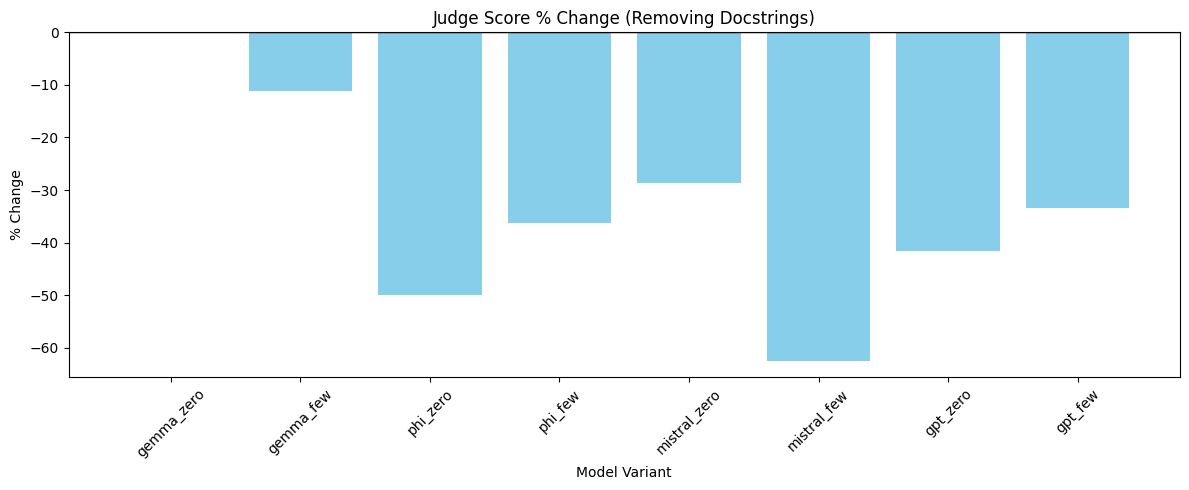

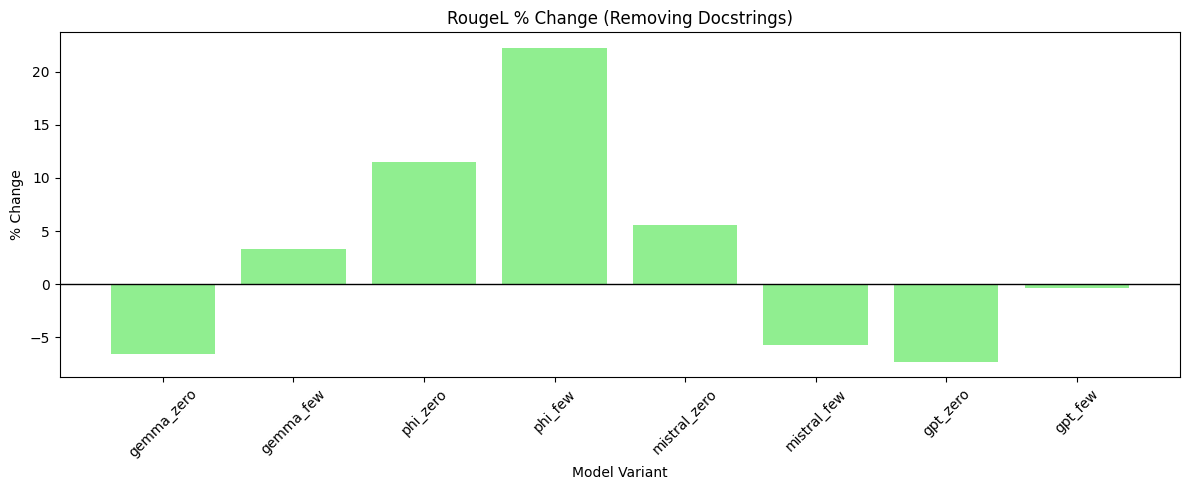

In [ ]:
df = summary_df.copy()

# Extract simple labels like: gemma_few, gemma_zero, phi_few, phi_zero, ...
df["label"] = df["csv"].str.replace("_docstr.csv", "", regex=False)

print("All 8 entries:")
print(df)

# ------------------------------
# Bar Plot: Judge Score Changes (8 bars)
# ------------------------------
plt.figure(figsize=(12, 5))
plt.bar(df["label"], df["avg_judge_pct"], color="skyblue")
plt.axhline(0, color="black", linewidth=1)
plt.title("Judge Score % Change (Removing Docstrings)")
plt.ylabel("% Change")
plt.xlabel("Model Variant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------
# Bar Plot: RougeL Changes (8 bars)
# ------------------------------
plt.figure(figsize=(12, 5))
plt.bar(df["label"], df["avg_rougeL_pct"], color="lightgreen")
plt.axhline(0, color="black", linewidth=1)
plt.title("RougeL % Change (Removing Docstrings)")
plt.ylabel("% Change")
plt.xlabel("Model Variant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Combined Model Averages:
     model  avg_judge_pct  avg_rougeL_pct
0    gemma      -5.555556       -1.657552
1      gpt     -37.500000       -3.811061
2  mistral     -45.535714       -0.082145
3      phi     -43.181818       16.863570


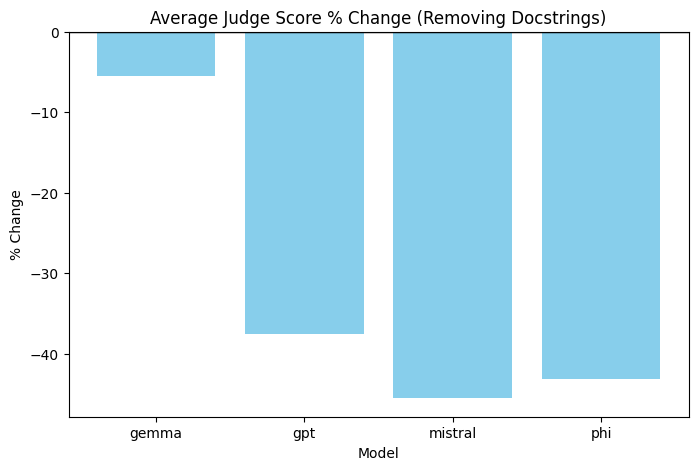

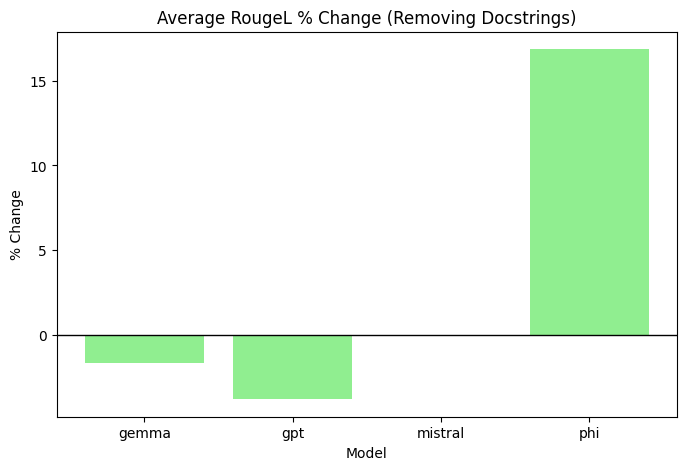

In [ ]:
df = summary_df.copy()

# Extract model names (gemma, phi, mistral, gpt4)
df["model"] = df["csv"].str.replace("_few_docstr.csv", "", regex=False)
df["model"] = df["model"].str.replace("_zero_docstr.csv", "", regex=False)

# Group by model → average zero + few
combined = df.groupby("model")[["avg_judge_pct", "avg_rougeL_pct"]].mean().reset_index()

print("Combined Model Averages:")
print(combined)

# ------------------------------
# Bar Plot: Judge Score Changes
# ------------------------------
plt.figure(figsize=(8, 5))
plt.bar(combined["model"], combined["avg_judge_pct"], color="skyblue")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Judge Score % Change (Removing Docstrings)")
plt.ylabel("% Change")
plt.xlabel("Model")
plt.show()

# ------------------------------
# Bar Plot: RougeL Changes
# ------------------------------
plt.figure(figsize=(8, 5))
plt.bar(combined["model"], combined["avg_rougeL_pct"], color="lightgreen")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average RougeL % Change (Removing Docstrings)")
plt.ylabel("% Change")
plt.xlabel("Model")
plt.show()
